In [1]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

c:\Users\Ahmet\workspace\homework1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets import load_dataset

ds = load_dataset("savasy/ttc4900", split="train")
ds

Dataset({
    features: ['category', 'text'],
    num_rows: 4900
})

In [3]:
from collections import Counter

labels = Counter([cat for cat in ds["category"]])
labels

Counter({0: 700, 1: 700, 2: 700, 3: 700, 4: 700, 5: 700, 6: 700})

In [4]:
from sklearn.model_selection import train_test_split

X, y = ds["text"], ds["category"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [5]:
import torch
from tqdm import tqdm

@torch.no_grad()
def encode(texts):
    embeddings = model.encode(texts, convert_to_numpy=True)
    return embeddings

batch_size = 16
print("Encoding train set...")
X_train_emb = [
    encode(X_train[i : i + batch_size]) for i in tqdm(range(0, len(X_train), batch_size), total=len(X_train)//batch_size)
]
print("Encoding test set...")
X_test_emb = [
    encode(X_test[i : i + batch_size]) for i in tqdm(range(0, len(X_test), batch_size), total=len(X_test)//batch_size)
]

Encoding train set...


215it [03:08,  1.14it/s]                         


Encoding test set...


92it [01:18,  1.17it/s]                        


In [6]:
import numpy as np

# Embeddings'leri birleştir
X_train_final = np.vstack(X_train_emb)
X_test_final = np.vstack(X_test_emb)

In [7]:
from sklearn.svm import SVC

# Model eğitimi
svm_clf = SVC(kernel="linear", random_state=42, probability=True)
svm_clf.fit(X_train_final, y_train)

# Tahminler
y_pred = svm_clf.predict(X_test_final)
y_pred_proba = svm_clf.predict_proba(X_test_final)

In [14]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report,
                           roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# Temel metrikler
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.8571
Precision: 0.8581
Recall: 0.8571
F1-Score: 0.8573


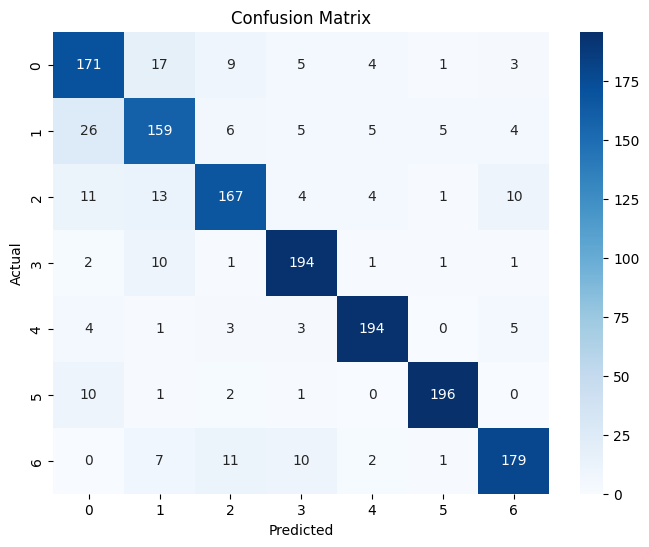

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [16]:
# Detaylı sınıflandırma raporu
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.81      0.79       210
           1       0.76      0.76      0.76       210
           2       0.84      0.80      0.82       210
           3       0.87      0.92      0.90       210
           4       0.92      0.92      0.92       210
           5       0.96      0.93      0.94       210
           6       0.89      0.85      0.87       210

    accuracy                           0.86      1470
   macro avg       0.86      0.86      0.86      1470
weighted avg       0.86      0.86      0.86      1470



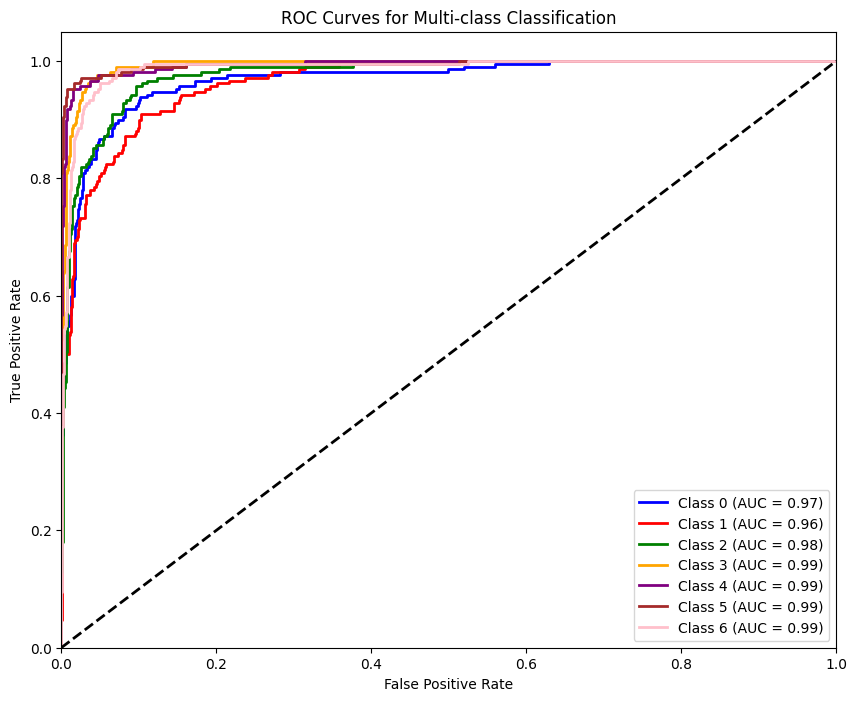

Macro AUC: 0.9828
Weighted AUC: 0.9828


In [17]:
# ROC Analizi (Multi-class için)
n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# Her sınıf için ROC eğrisi
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, 
             label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Multi-class Classification')
plt.legend(loc="lower right")
plt.show()

# Macro ve Micro AUC
macro_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
weighted_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
print(f"Macro AUC: {macro_auc:.4f}")
print(f"Weighted AUC: {weighted_auc:.4f}")

In [18]:
from sklearn.metrics import balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef

# Ek metrikler
balanced_acc = balanced_accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred)

print(f"\nAdditional Metrics:")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")

# Sınıf bazında metrikler
precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

print(f"\nPer-class Metrics:")
for i in range(n_classes):
    print(f"Class {i} - Precision: {precision_per_class[i]:.4f}, "
          f"Recall: {recall_per_class[i]:.4f}, F1: {f1_per_class[i]:.4f}")


Additional Metrics:
Balanced Accuracy: 0.8571
Cohen's Kappa: 0.8333

Per-class Metrics:
Class 0 - Precision: 0.7634, Recall: 0.8143, F1: 0.7880
Class 1 - Precision: 0.7644, Recall: 0.7571, F1: 0.7608
Class 2 - Precision: 0.8392, Recall: 0.7952, F1: 0.8166
Class 3 - Precision: 0.8739, Recall: 0.9238, F1: 0.8981
Class 4 - Precision: 0.9238, Recall: 0.9238, F1: 0.9238
Class 5 - Precision: 0.9561, Recall: 0.9333, F1: 0.9446
Class 6 - Precision: 0.8861, Recall: 0.8524, F1: 0.8689


In [19]:
# Tüm metriklerin özeti
import pandas as pd

metrics_summary = {
    'Metric': ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 
               'F1-Score (Weighted)', 'Balanced Accuracy', 'Cohens Kappa',
               'Macro AUC', 'Weighted AUC'],
    'Score': [accuracy, precision, recall, f1, balanced_acc, kappa, macro_auc, weighted_auc]
}

df_metrics = pd.DataFrame(metrics_summary)
print("\nMetrics Summary:")
print(df_metrics.to_string(index=False, float_format='%.4f'))


Metrics Summary:
              Metric  Score
            Accuracy 0.8571
Precision (Weighted) 0.8581
   Recall (Weighted) 0.8571
 F1-Score (Weighted) 0.8573
   Balanced Accuracy 0.8571
        Cohens Kappa 0.8333
           Macro AUC 0.9828
        Weighted AUC 0.9828
